# 02 — Graph Construction

Build the two typed product graphs (substitutes, complements) and train Node2Vec embeddings. Outputs are saved to `data/processed/` for use in subsequent modelling notebooks.

**Pipeline:**
1. Build the store × product × week panel
2. Compute complement edges (basket co-occurrence + PPMI)
3. Train Node2Vec embeddings on the complement graph
4. Build substitute edges (SUB_COMMODITY_DESC + embedding reweighting)
5. Add spillover features to the panel
6. Inspect and save outputs

In [1]:
import sys
from pathlib import Path

# Make src importable from the notebook
repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import networkx as nx

from src.data.panel_builder import build_panel
from src.graph.co_purchase import build_complement_adjacency
from src.graph.substitute import build_substitute_adjacency
from src.graph.embeddings import train_node2vec
from src.graph.spillover_features import add_spillover_features

DATA_RAW = repo_root / "data" / "raw"
DATA_PROCESSED = repo_root / "data" / "processed"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

print("repo root:", repo_root)
print("raw data files:", sorted(p.name for p in DATA_RAW.iterdir()))

repo root: /Users/dmmckinn/repos/graph-causal-pricing
raw data files: ['campaign_desc.csv', 'campaign_table.csv', 'causal_data.csv', 'coupon.csv', 'coupon_redempt.csv', 'hh_demographic.csv', 'product.csv', 'transaction_data.csv']


## 1 — Build the store × product × week panel

Aggregate transaction data to the (STORE_ID, PRODUCT_ID, WEEK_NO) grain, join promotional flags from `causal_data`, and fill zero-unit observations across the full Cartesian product.

In [2]:
panel = build_panel(
    transaction_path=str(DATA_RAW / "transaction_data.csv"),
    causal_path=str(DATA_RAW / "causal_data.csv"),
    product_path=str(DATA_RAW / "product.csv"),
)

print(f"Panel shape: {panel.shape}")
print(f"\nColumns:\n{panel.columns.tolist()}")
print(f"\nZero-unit rows: {(panel['units_sold'] == 0).sum():,}  "
      f"({(panel['units_sold'] == 0).mean():.1%} of panel)")
print(f"Treated rows (promo_any=1): {panel['promo_any'].sum():,}  "
      f"({panel['promo_any'].mean():.1%})")
panel.head()

Panel shape: (73464639, 15)

Columns:
['STORE_ID', 'PRODUCT_ID', 'WEEK_NO', 'units_sold', 'sales_value', 'retail_disc_total', 'discount_rate', 'sold_any', 'display', 'mailer', 'promo_any', 'DEPARTMENT', 'COMMODITY_DESC', 'SUB_COMMODITY_DESC', 'BRAND']

Zero-unit rows: 71,104,857  (96.8% of panel)
Treated rows (promo_any=1): 6,741,055  (9.2%)


,STORE_ID,PRODUCT_ID,WEEK_NO,units_sold,sales_value,retail_disc_total,discount_rate,sold_any,display,mailer,promo_any,DEPARTMENT,COMMODITY_DESC,SUB_COMMODITY_DESC,BRAND
0,3191,25671,23,0.0,0.0,0.0,0.0,0,0,0,0,GROCERY,FRZN ICE,ICE - CRUSHED/CUBED,National
1,3191,25671,24,0.0,0.0,0.0,0.0,0,0,0,0,GROCERY,FRZN ICE,ICE - CRUSHED/CUBED,National
2,3191,25671,25,0.0,0.0,0.0,0.0,0,0,0,0,GROCERY,FRZN ICE,ICE - CRUSHED/CUBED,National
3,3191,25671,26,0.0,0.0,0.0,0.0,0,0,0,0,GROCERY,FRZN ICE,ICE - CRUSHED/CUBED,National
4,3191,25671,27,0.0,0.0,0.0,0.0,0,0,0,0,GROCERY,FRZN ICE,ICE - CRUSHED/CUBED,National


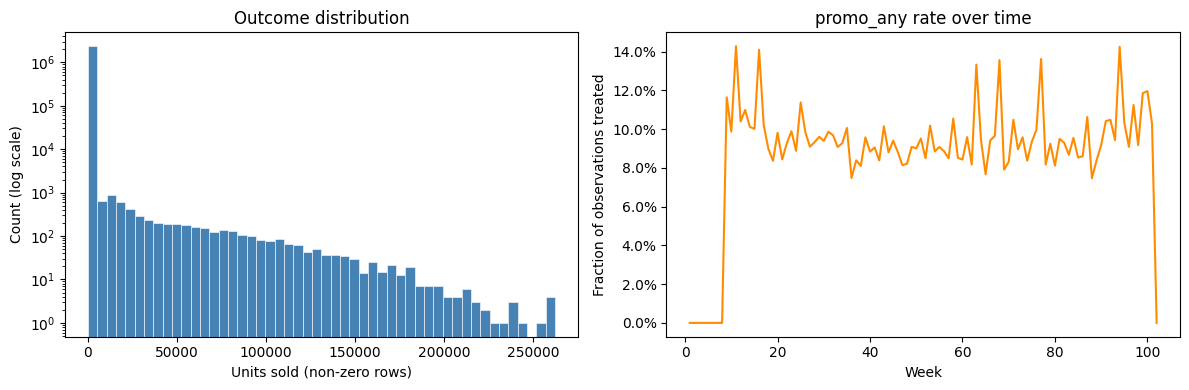

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Units sold distribution (log scale, non-zero rows)
sold = panel.loc[panel["units_sold"] > 0, "units_sold"]
axes[0].hist(sold, bins=50, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].set_yscale("log")
axes[0].set_xlabel("Units sold (non-zero rows)")
axes[0].set_ylabel("Count (log scale)")
axes[0].set_title("Outcome distribution")

# Treatment rate per week
weekly_treat = panel.groupby("WEEK_NO")["promo_any"].mean()
axes[1].plot(weekly_treat.index, weekly_treat.values, color="darkorange", linewidth=1.5)
axes[1].set_xlabel("Week")
axes[1].set_ylabel("Fraction of observations treated")
axes[1].set_title("promo_any rate over time")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

## 2 — Complement graph (basket co-occurrence + PPMI)

Products are connected if they are bought together in the same basket at least 10 times. Edge weights are Positive PMI values, normalised to [0, 1]. We use all ~3,000 transacted products for the graph.

In [4]:
A_comp, comp_pid_idx = build_complement_adjacency(
    transaction_path=str(DATA_RAW / "transaction_data.csv"),
    min_cooccurrence=10,
)

n_nodes = len(comp_pid_idx)
n_edges = A_comp.nnz // 2  # symmetric, so halve
density = A_comp.nnz / (n_nodes * (n_nodes - 1))

print(f"Complement graph — nodes: {n_nodes:,}  |  edges: {n_edges:,}  |  density: {density:.4%}")
print(f"Edge weight range: [{A_comp.data.min():.4f}, {A_comp.data.max():.4f}]")

Complement graph — nodes: 92,339  |  edges: 223,924  |  density: 0.0053%
Edge weight range: [0.0000, 1.0000]


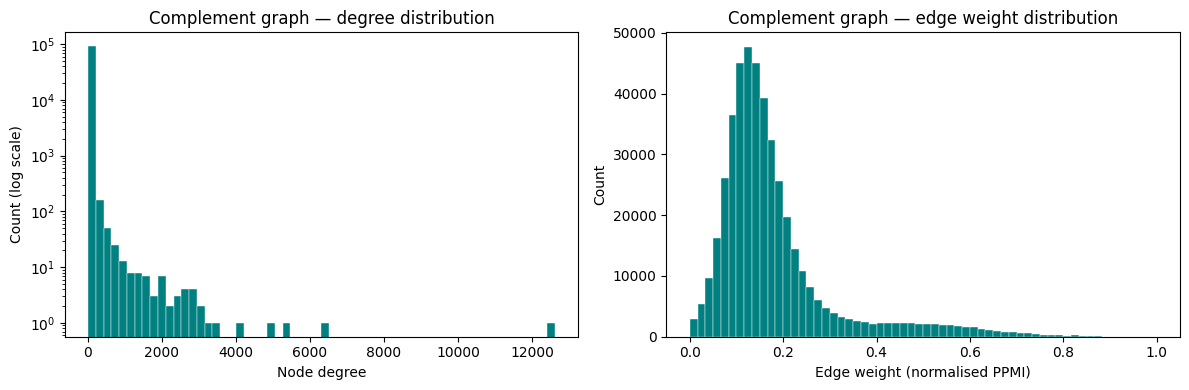

In [5]:
# Degree distribution for the complement graph
G_comp = nx.from_scipy_sparse_array(A_comp)
degrees = [d for _, d in G_comp.degree()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(degrees, bins=60, color="teal", edgecolor="white", linewidth=0.3)
axes[0].set_yscale("log")
axes[0].set_xlabel("Node degree")
axes[0].set_ylabel("Count (log scale)")
axes[0].set_title("Complement graph — degree distribution")

axes[1].hist(A_comp.data, bins=60, color="teal", edgecolor="white", linewidth=0.3)
axes[1].set_xlabel("Edge weight (normalised PPMI)")
axes[1].set_ylabel("Count")
axes[1].set_title("Complement graph — edge weight distribution")

plt.tight_layout()
plt.show()

## 3 — Node2Vec embeddings

Train biased random walk embeddings (p=1, q=1 → DeepWalk unbiased baseline) on the complement co-occurrence graph. These embeddings serve two purposes: (1) reweighting substitute edges by purchase-pattern similarity, and (2) as product-level features in the causal model.

In [6]:
embeddings, emb_pid_idx = train_node2vec(
    A=A_comp,
    pid_idx=comp_pid_idx,
    dim=64,
    num_walks=10,
    walk_length=80,
    p=1.0,
    q=1.0,
    workers=4,
    seed=42,
)

print(f"Embedding matrix: {embeddings.shape}  (products × dimensions)")
print(f"Non-zero rows: {(embeddings.any(axis=1)).sum():,}  "
      f"({(embeddings.any(axis=1)).mean():.1%} of nodes trained)")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Embedding matrix: (92339, 64)  (products × dimensions)
Non-zero rows: 92,339  (100.0% of nodes trained)


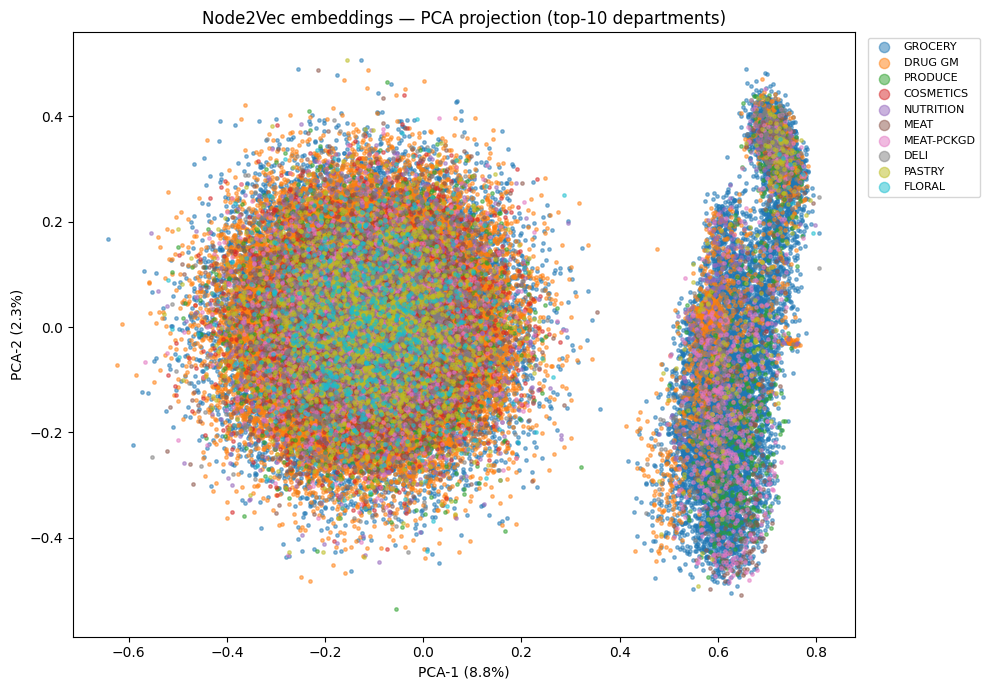

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

# Project to 2D via PCA for visual inspection
trained_mask = embeddings.any(axis=1)
emb_trained = embeddings[trained_mask]
pids_trained = emb_pid_idx[trained_mask]

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(normalize(emb_trained, norm="l2"))

# Colour by department (join from product.csv)
product_meta = pd.read_csv(DATA_RAW / "product.csv")[["PRODUCT_ID", "DEPARTMENT"]].drop_duplicates()
pid_dept = dict(zip(product_meta["PRODUCT_ID"], product_meta["DEPARTMENT"]))
depts = [pid_dept.get(int(p), "UNKNOWN") for p in pids_trained]
dept_series = pd.Categorical(depts)

fig, ax = plt.subplots(figsize=(10, 7))
for dept_name in pd.Series(depts).value_counts().head(10).index:
    mask = np.array(depts) == dept_name
    ax.scatter(coords[mask, 0], coords[mask, 1], s=6, alpha=0.5, label=dept_name)

ax.set_xlabel(f"PCA-1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PCA-2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("Node2Vec embeddings — PCA projection (top-10 departments)")
ax.legend(markerscale=3, fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4 — Substitute graph (hierarchy + embedding reweighting)

Connect products sharing the same `SUB_COMMODITY_DESC` (coarse tier), then reweight each edge by the cosine similarity of their Node2Vec embeddings (fine-grained tier). Capped at 50 neighbours per node.

In [8]:
A_sub, sub_pid_idx = build_substitute_adjacency(
    product_path=str(DATA_RAW / "product.csv"),
    product_ids=comp_pid_idx.tolist(),   # align index with complement graph
    embeddings=embeddings,
    emb_pid_idx=emb_pid_idx,
    max_neighbors=50,
)

n_sub_edges = A_sub.nnz // 2
sub_density = A_sub.nnz / (len(sub_pid_idx) * (len(sub_pid_idx) - 1))

print(f"Substitute graph — nodes: {len(sub_pid_idx):,}  |  edges: {n_sub_edges:,}  |  density: {sub_density:.4%}")
print(f"Edge weight range: [{A_sub.data.min():.4f}, {A_sub.data.max():.4f}]")

Substitute graph — nodes: 92,339  |  edges: 1,885,397  |  density: 0.0442%
Edge weight range: [0.0000, 0.9998]


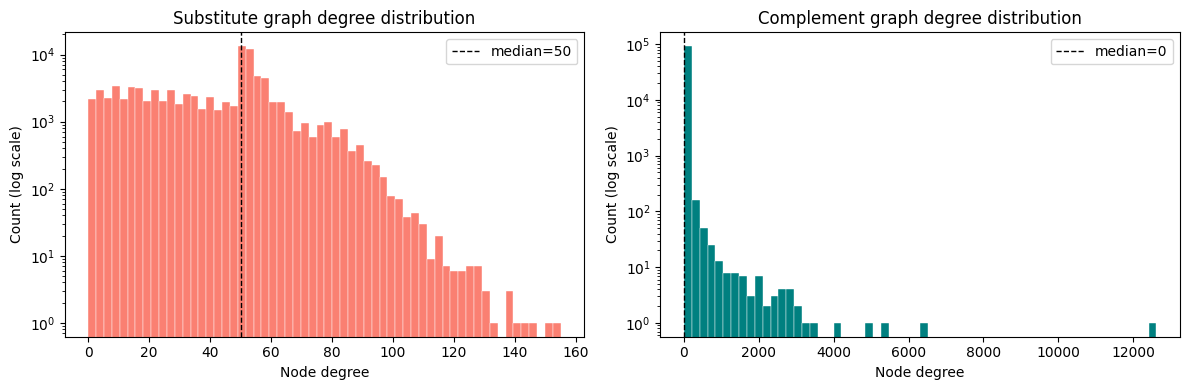

In [9]:
# Compare degree distributions: substitutes vs complements
G_sub = nx.from_scipy_sparse_array(A_sub)
sub_degrees = [d for _, d in G_sub.degree()]
comp_degrees_aligned = [G_comp.degree(i) for i in range(len(comp_pid_idx)) if G_comp.has_node(i)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, deg, label, color in zip(
    axes,
    [sub_degrees, degrees],
    ["Substitute graph", "Complement graph"],
    ["salmon", "teal"],
):
    ax.hist(deg, bins=60, color=color, edgecolor="white", linewidth=0.3)
    ax.set_yscale("log")
    ax.set_xlabel("Node degree")
    ax.set_ylabel("Count (log scale)")
    ax.set_title(f"{label} degree distribution")
    ax.axvline(np.median(deg), color="black", linestyle="--", linewidth=1, label=f"median={np.median(deg):.0f}")
    ax.legend()

plt.tight_layout()
plt.show()

In [10]:
# Spot-check: sample substitute pairs and inspect their labels
product_meta_full = pd.read_csv(DATA_RAW / "product.csv")[
    ["PRODUCT_ID", "DEPARTMENT", "COMMODITY_DESC", "SUB_COMMODITY_DESC"]
].set_index("PRODUCT_ID")

cx = A_sub.tocoo()
edge_sample = pd.DataFrame({
    "pid_a": sub_pid_idx[cx.row],
    "pid_b": sub_pid_idx[cx.col],
    "weight": cx.data,
}).drop_duplicates(subset=["pid_a", "pid_b"])
edge_sample = edge_sample[edge_sample["pid_a"] < edge_sample["pid_b"]].sample(10, random_state=42)

for _, row in edge_sample.iterrows():
    a, b = int(row["pid_a"]), int(row["pid_b"])
    meta_a = product_meta_full.loc[a] if a in product_meta_full.index else {}
    meta_b = product_meta_full.loc[b] if b in product_meta_full.index else {}
    print(f"w={row['weight']:.3f}  {meta_a.get('SUB_COMMODITY_DESC','?')} | "
          f"{meta_b.get('SUB_COMMODITY_DESC','?')}")

w=0.469  TRADITIONAL | TRADITIONAL
w=0.028  JHOOK - HOUSEWARE | JHOOK - HOUSEWARE
w=0.059  FRZN BREADED PREPARED CHICK | FRZN BREADED PREPARED CHICK
w=0.164  SHAMPOO | SHAMPOO
w=0.158  CHILI SAUCE COCKTAIL SAUCE | CHILI SAUCE COCKTAIL SAUCE
w=0.029  MISC. HAIR CARE | MISC. HAIR CARE
w=0.068  HAIR COMBS AND BRUSHES | HAIR COMBS AND BRUSHES
w=0.200  STUFFED/MIXED PORK | STUFFED/MIXED PORK
w=0.044  RAWHIDE CHEWS | RAWHIDE CHEWS
w=0.178  MISCELLANEOUS CHEESE | MISCELLANEOUS CHEESE


## 5 — Add spillover features to the panel

For each (store, product, week) observation, count how many substitute and complement graph-neighbours were on promotion in the same store-week, and compute the average neighbour unit sales.

In [11]:
panel_with_spillover = add_spillover_features(
    panel=panel,
    A_sub=A_sub,
    sub_pid_idx=sub_pid_idx,
    A_comp=A_comp,
    comp_pid_idx=comp_pid_idx,
)

print(f"Panel with spillover features: {panel_with_spillover.shape}")
print("\nNew columns:")
spillover_cols = [c for c in panel_with_spillover.columns if "substitute" in c or "complement" in c]
print(panel_with_spillover[spillover_cols].describe().round(3))

/Users/dmmckinn/repos/graph-causal-pricing/src/graph/spillover_features.py:122: RuntimeWarning: invalid value encountered in divide
  n_present_sub > 0, n_treated_sub / n_present_sub, 0.0
/Users/dmmckinn/repos/graph-causal-pricing/src/graph/spillover_features.py:125: RuntimeWarning: invalid value encountered in divide
  n_present_sub > 0, sum_units_sub / n_present_sub, 0.0
/Users/dmmckinn/repos/graph-causal-pricing/src/graph/spillover_features.py:130: RuntimeWarning: invalid value encountered in divide
  n_present_comp > 0, n_treated_comp / n_present_comp, 0.0
/Users/dmmckinn/repos/graph-causal-pricing/src/graph/spillover_features.py:133: RuntimeWarning: invalid value encountered in divide
  n_present_comp > 0, sum_units_comp / n_present_comp, 0.0


Panel with spillover features: (73464639, 21)

New columns:
       n_treated_substitutes  frac_treated_substitutes  avg_units_substitutes  \
count           7.346464e+07              7.346464e+07           7.346464e+07   
mean            1.613000e+00              9.000000e-02           3.494000e+00   
std             4.041000e+00              1.790000e-01           3.269850e+02   
min             0.000000e+00              0.000000e+00           0.000000e+00   
25%             0.000000e+00              0.000000e+00           0.000000e+00   
50%             0.000000e+00              0.000000e+00           0.000000e+00   
75%             1.000000e+00              1.070000e-01           0.000000e+00   
max             7.200000e+01              1.000000e+00           1.063147e+05   

       n_treated_complements  frac_treated_complements  avg_units_complements  
count           7.346464e+07              7.346464e+07           7.346464e+07  
mean            8.465000e+00              1.690000

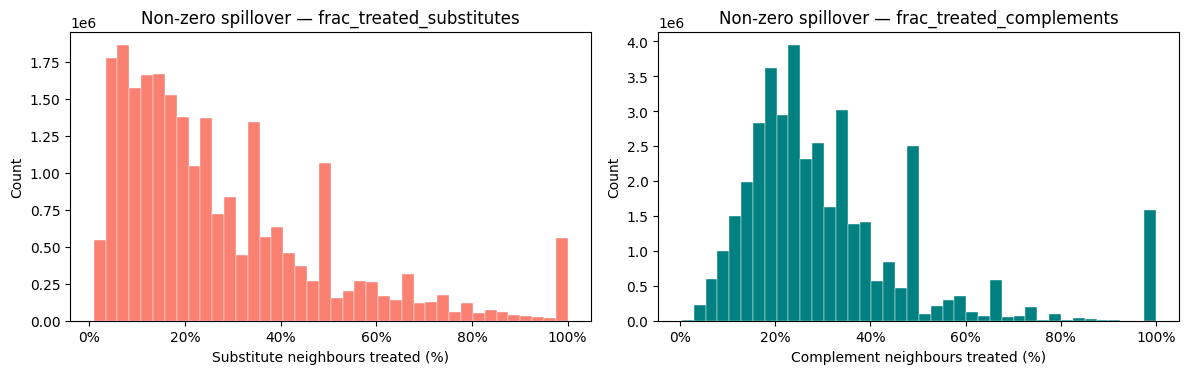


Rows with ≥1 treated substitute neighbour: 24,063,601
Rows with ≥1 treated complement neighbour: 39,144,548


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, color, label in zip(
    axes,
    ["frac_treated_substitutes", "frac_treated_complements"],
    ["salmon", "teal"],
    ["Substitute neighbours treated (%)", "Complement neighbours treated (%)"],
):
    vals = panel_with_spillover.loc[panel_with_spillover[col] > 0, col]
    ax.hist(vals, bins=40, color=color, edgecolor="white", linewidth=0.3)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"Non-zero spillover — {col}")
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

print(f"\nRows with ≥1 treated substitute neighbour: "
      f"{(panel_with_spillover['n_treated_substitutes'] > 0).sum():,}")
print(f"Rows with ≥1 treated complement neighbour: "
      f"{(panel_with_spillover['n_treated_complements'] > 0).sum():,}")

## 6 — Save outputs

Persist all artefacts to `data/processed/` for use in causal modelling notebooks.

In [13]:
import numpy as np

# Panel (parquet for columnar efficiency)
panel_with_spillover.to_parquet(DATA_PROCESSED / "panel.parquet", index=False)
print(f"Saved panel:  {DATA_PROCESSED / 'panel.parquet'}")

# Sparse adjacency matrices (scipy npz format)
sp.save_npz(str(DATA_PROCESSED / "A_sub.npz"), A_sub)
sp.save_npz(str(DATA_PROCESSED / "A_comp.npz"), A_comp)
print(f"Saved A_sub:  {DATA_PROCESSED / 'A_sub.npz'}")
print(f"Saved A_comp: {DATA_PROCESSED / 'A_comp.npz'}")

# Product index (shared by both matrices — aligned to comp_pid_idx)
np.save(str(DATA_PROCESSED / "pid_idx.npy"), comp_pid_idx)
print(f"Saved pid_idx: {DATA_PROCESSED / 'pid_idx.npy'}")

# Embeddings
np.save(str(DATA_PROCESSED / "embeddings.npy"), embeddings)
np.save(str(DATA_PROCESSED / "emb_pid_idx.npy"), emb_pid_idx)
print(f"Saved embeddings: {DATA_PROCESSED / 'embeddings.npy'}")

print("\nAll artefacts saved.")

Saved panel:  /Users/dmmckinn/repos/graph-causal-pricing/data/processed/panel.parquet
Saved A_sub:  /Users/dmmckinn/repos/graph-causal-pricing/data/processed/A_sub.npz
Saved A_comp: /Users/dmmckinn/repos/graph-causal-pricing/data/processed/A_comp.npz
Saved pid_idx: /Users/dmmckinn/repos/graph-causal-pricing/data/processed/pid_idx.npy
Saved embeddings: /Users/dmmckinn/repos/graph-causal-pricing/data/processed/embeddings.npy

All artefacts saved.
